# 1. Data Loading & Exploration

Question 1
Load the dataset fitness_tracker_logs.csv into a Pandas DataFrame. Display the first 8 rows of the dataset, and programmatically print out the total number of rows and columns present in the file.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Users/dipusardar/DIPU/Programming/Data-Analysis/Project 05/fitness_tracker_logs.csv')

print(df.head(8))
print(df.shape)

    Log_ID        Date  User_ID  Age  Gender             Device_Type    Steps  \
0  FT-1001  2026-03-31  USR-121   49  Female           Garmin Venu 3  10984.0   
1  FT-1002  2026-02-19  USR-104   45  Female         Fitbit Charge 5   9309.0   
2  FT-1003  2026-03-05  USR-101   38    Male  Samsung Galaxy Watch 6  13634.0   
3  FT-1004  2026-02-21  USR-124   51  Female  Samsung Galaxy Watch 6  11549.0   
4  FT-1005  2026-02-01  USR-109   36    Male    Apple Watch Series 9   6370.0   
5  FT-1006  2026-01-19  USR-108   30    Male  Samsung Galaxy Watch 6   8610.0   
6  FT-1007  2026-03-25  USR-108   30    Male  Samsung Galaxy Watch 6   9727.0   
7  FT-1008  2026-03-30  USR-105   51  Female    Apple Watch Series 9   6938.0   

   Distance_km  Calories_Burned  Active_Minutes  Sleep_Duration_Hours  \
0         7.56             2400            98.0                   6.8   
1         7.37             2176           100.0                   8.5   
2         9.93             2345            98.0    

Question 2
Inspect the dataset's metadata. Print out the data types of all columns and determine the exact number of missing (null) values inside each column. Which columns contain missing data?

In [29]:
print('===Print the datatype of all columns===')
print(df.dtypes)

print('')
print('-' * 50)
print('===Exect number of missing values===')
print(df.isnull().any())



===Print the datatype of all columns===
Log_ID                      str
Date                        str
User_ID                     str
Age                       int64
Gender                      str
Device_Type                 str
Steps                   float64
Distance_km             float64
Calories_Burned           int64
Active_Minutes          float64
Sleep_Duration_Hours    float64
Heart_Rate_Avg            int64
Weather_Condition           str
dtype: object

--------------------------------------------------
===Exect number of missing values===
Log_ID                  False
Date                    False
User_ID                 False
Age                     False
Gender                  False
Device_Type             False
Steps                    True
Distance_km             False
Calories_Burned         False
Active_Minutes           True
Sleep_Duration_Hours     True
Heart_Rate_Avg          False
Weather_Condition        True
dtype: bool


# 2. Data Cleaning & Manipulation

Question 3
Handle the missing values in the dataset using the following specific strategy:

For the numerical columns Steps and Active_Minutes, fill the missing values with their respective column median.

For rows where Sleep_Duration_Hours or Weather_Condition is missing, drop those rows completely from the DataFrame.

Verify that your final clean DataFrame no longer contains any missing values.

In [30]:

print(df.columns)
print()
print('-'* 50)

print(df['Steps'].isnull().any())

steps_median = df['Steps'].median()
df['Steps'] = df['Steps'].fillna(steps_median)

print(df['Steps'].isnull().any())

print('-'*50)
Active_Minutes_median = df['Active_Minutes'].median()
df['Active_Minutes'] = df['Active_Minutes'].fillna('Active_Minutes_median')



Index(['Log_ID', 'Date', 'User_ID', 'Age', 'Gender', 'Device_Type', 'Steps',
       'Distance_km', 'Calories_Burned', 'Active_Minutes',
       'Sleep_Duration_Hours', 'Heart_Rate_Avg', 'Weather_Condition'],
      dtype='str')

--------------------------------------------------
True
False
--------------------------------------------------


In [31]:
df = df.dropna(subset=['Sleep_Duration_Hours','Weather_Condition'])

In [32]:
print(df.isnull().sum())

Log_ID                  0
Date                    0
User_ID                 0
Age                     0
Gender                  0
Device_Type             0
Steps                   0
Distance_km             0
Calories_Burned         0
Active_Minutes          0
Sleep_Duration_Hours    0
Heart_Rate_Avg          0
Weather_Condition       0
dtype: int64


Question 4
Transform the time-series elements:

Convert the Date column from an object/string data type into a proper pandas datetime object.

Create a new column named Month that extracts the full month name (e.g., January, February) from the Date column.

In [33]:
print(df.columns)
print('_'*100)

print(df['Date'])
df['Date'] = pd.to_datetime(df['Date'])

print(df['Date'])



Index(['Log_ID', 'Date', 'User_ID', 'Age', 'Gender', 'Device_Type', 'Steps',
       'Distance_km', 'Calories_Burned', 'Active_Minutes',
       'Sleep_Duration_Hours', 'Heart_Rate_Avg', 'Weather_Condition'],
      dtype='str')
____________________________________________________________________________________________________
0      2026-03-31
1      2026-02-19
2      2026-03-05
4      2026-02-01
5      2026-01-19
          ...    
545    2026-02-27
546    2026-03-10
547    2026-03-03
548    2026-02-14
549    2026-02-12
Name: Date, Length: 500, dtype: str
0     2026-03-31
1     2026-02-19
2     2026-03-05
4     2026-02-01
5     2026-01-19
         ...    
545   2026-02-27
546   2026-03-10
547   2026-03-03
548   2026-02-14
549   2026-02-12
Name: Date, Length: 500, dtype: datetime64[us]


In [34]:
df['Month'] = df['Date'].dt.strftime('%B')
print(df['Month'])

0         March
1      February
2         March
4      February
5       January
         ...   
545    February
546       March
547       March
548    February
549    February
Name: Month, Length: 500, dtype: str


Question 5
Filter the dataset to isolate high-performing days:

Find all log entries where the user achieved more than 10,000 steps AND burned more than 2,500 calories.

Sort this filtered subset by Calories_Burned in descending order, and display the top 5 records.

In [35]:
print(df.columns)
print(df[['Steps','Calories_Burned']])
print()
print('-' * 100)

print('===Finding the values===')
find = df[(df['Steps'] > 10000) & (df['Calories_Burned'] > 2500)]
print(find)
print()
print('-' * 100)

print('===Sorting Values===')
sorting = find.sort_values(by='Calories_Burned', ascending=False)
print(sorting.head(5))



Index(['Log_ID', 'Date', 'User_ID', 'Age', 'Gender', 'Device_Type', 'Steps',
       'Distance_km', 'Calories_Burned', 'Active_Minutes',
       'Sleep_Duration_Hours', 'Heart_Rate_Avg', 'Weather_Condition', 'Month'],
      dtype='str')
       Steps  Calories_Burned
0    10984.0             2400
1     9309.0             2176
2    13634.0             2345
4     6370.0             1737
5     8610.0             2061
..       ...              ...
545   9202.0             2160
546   9533.0             2087
547  10854.0             2207
548  11232.0             2254
549   9839.5             2334

[500 rows x 2 columns]

----------------------------------------------------------------------------------------------------
===Finding the values===
      Log_ID       Date  User_ID  Age      Gender             Device_Type  \
9    FT-1010 2026-01-14  USR-104   45      Female         Fitbit Charge 5   
34   FT-1035 2026-01-21  USR-109   36        Male    Apple Watch Series 9   
51   FT-1052 2026-02-12

# 3. Mathematical & Statistical Analysis

Question 6
Use NumPy functions on your clean DataFrame to compute the following metrics for the Heart_Rate_Avg column:

Overall arithmetic mean
Median value
Standard deviation
25th and 75th percentiles

In [36]:
print(df.columns)
print('-' * 100)

heart_rate_data = df['Heart_Rate_Avg']

Heart_rate_mean = np.mean(heart_rate_data)
Heart_rate_median = np.median(heart_rate_data)
Heart_rate_std = np.std(heart_rate_data)

Heart_rate_25 = np.percentile(heart_rate_data, 25)
Heart_rate_75 = np.percentile(heart_rate_data, 75)

print(f"The mean: {Heart_rate_mean}")
print(f"The median: {Heart_rate_median}")
print(f"The Standard Daviation: {Heart_rate_std}")
print(f"The 25th Percentiles: {Heart_rate_25}")
print(f"The 75th Percentiles: {Heart_rate_75}")



Index(['Log_ID', 'Date', 'User_ID', 'Age', 'Gender', 'Device_Type', 'Steps',
       'Distance_km', 'Calories_Burned', 'Active_Minutes',
       'Sleep_Duration_Hours', 'Heart_Rate_Avg', 'Weather_Condition', 'Month'],
      dtype='str')
----------------------------------------------------------------------------------------------------
The mean: 79.32
The median: 80.0
The Standard Daviation: 6.156102663211522
The 25th Percentiles: 75.0
The 75th Percentiles: 84.0


Question 7
Analyze device performance using aggregations:

Group the data by Device_Type.
Compute both the average Distance_km covered and the total Calories_Burned for each device tracker.
Rename the aggregated columns to Average_Distance_km and Total_Calories_Burned respectively.

In [42]:
Device_States = df.groupby('Device_Type').agg({
    'Distance_km' : 'mean',
    'Calories_Burned' : 'sum'
}).reset_index()

print(Device_States)

              Device_Type  Distance_km  Calories_Burned
0    Apple Watch Series 9     7.667465           308686
1         Fitbit Charge 5     7.784958           260699
2           Garmin Venu 3     7.626897           314229
3  Samsung Galaxy Watch 6     7.709043           205784


In [43]:
#changing the name of the columns 
Change_column_Names = Device_States.rename(columns={
    'Distance_km' : 'Average_Distance_km',
    'Calories_Burned' : 'Total_Calories_Burned'
})

print(Change_column_Names)

              Device_Type  Average_Distance_km  Total_Calories_Burned
0    Apple Watch Series 9             7.667465                 308686
1         Fitbit Charge 5             7.784958                 260699
2           Garmin Venu 3             7.626897                 314229
3  Samsung Galaxy Watch 6             7.709043                 205784


Question 8
Explore relationship matrices:

Compute the Pearson correlation matrix for all numerical variables (Age, Steps, Distance_km, Calories_Burned, Active_Minutes, Sleep_Duration_Hours, Heart_Rate_Avg).
Identify which pair of variables displays the strongest positive correlation.

In [ ]:
import pandas as pd

print("=== Pearson Correlation Matrix ===")

# ১. শুধুমাত্র নিউমেরিক্যাল কলামগুলোকে সিলেক্ট করা
numerical_columns = ['Age', 'Steps', 'Distance_km', 'Calories_Burned', 'Active_Minutes', 'Sleep_Duration_Hours', 'Heart_Rate_Avg']

# ২. কোরিলেশন ম্যাট্রিক্স তৈরি করা
correlation_matrix = df[numerical_columns].corr()

# ম্যাট্রিক্সটি প্রিন্ট করে দেখা
print(correlation_matrix)
print("\n" + "-"*50 + "\n")

In [49]:
import pandas as pd
import numpy as np

print("=== Pearson Correlation Matrix ===")

# ১. কোরিলেশন করার আগে নিশ্চিত হয়ে নেওয়া যে কোনো কলাম অবজেক্ট টাইপ হয়ে নেই তো?
# আমরা কোশ্চেন ৩ এর সেই ভুলটি এখানে শুধরে নিচ্ছি মেমরির জন্য:
if df['Active_Minutes'].dtype == 'object':
    # যদি স্ট্রিং হয়ে থাকে, তবে সেটিকে সংখ্যায় রূপান্তর করো এবং এরর থাকলে তা NaN করো
    df['Active_Minutes'] = pd.to_numeric(df['Active_Minutes'], errors='coerce')
    # এরপর সেটিকে আবার মিডিয়ান দিয়ে ফিল করো
    df['Active_Minutes'] = df['Active_Minutes'].fillna(df['Active_Minutes'].median())

# ২. নিউমেরিক্যাল কলামগুলোর লিস্ট
numerical_columns = ['Age', 'Steps', 'Distance_km', 'Calories_Burned', 'Active_Minutes', 'Sleep_Duration_Hours', 'Heart_Rate_Avg']

# ৩. কোরিলেশন ম্যাট্রিক্স তৈরি করা (numeric_only=True দিলে প্যান্ডাস আরও সেফলি কাজ করে)
correlation_matrix = df[numerical_columns].corr(numeric_only=True)

# ৪. ম্যাট্রিক্সটি প্রিন্ট করা
print(correlation_matrix)

=== Pearson Correlation Matrix ===
                           Age     Steps  Distance_km  Calories_Burned  \
Age                   1.000000  0.008207     0.007309        -0.019239   
Steps                 0.008207  1.000000     0.948973         0.769174   
Distance_km           0.007309  0.948973     1.000000         0.783520   
Calories_Burned      -0.019239  0.769174     0.783520         1.000000   
Active_Minutes       -0.015054  0.796474     0.792164         0.779127   
Sleep_Duration_Hours -0.001257  0.087032     0.076207         0.061390   
Heart_Rate_Avg        0.016586  0.263401     0.262964         0.221627   

                      Active_Minutes  Sleep_Duration_Hours  Heart_Rate_Avg  
Age                        -0.015054             -0.001257        0.016586  
Steps                       0.796474              0.087032        0.263401  
Distance_km                 0.792164              0.076207        0.262964  
Calories_Burned             0.779127              0.061390      

# 4. Data Visualization

Question 9
Using Seaborn and Matplotlib, create a clean, professional bar plot that illustrates the average number of Steps taken across different Weather_Condition categories.

Ensure your plot contains descriptive X and Y axis labels, a prominent title, and a cohesive color palette (e.g., muted or viridis).


/var/folders/8n/zv2nb4gs3nv69pw2dn0tg97w0000gn/T/ipykernel_6645/1956184762.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Text(0.5, 1.0, 'Steps & Weather condition Bar chart')

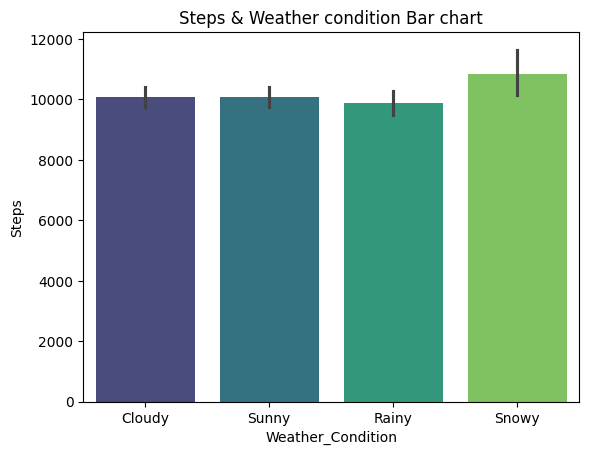

In [53]:
import seaborn as sns
sns.barplot(
    x = df['Weather_Condition'],
    y = df['Steps'],

    palette='viridis'
)

plt.title('Steps & Weather condition Bar chart')

Question 10
Generate a scatter plot using Matplotlib or Seaborn to map the relationship between Active_Minutes (X-axis) and Calories_Burned (Y-axis).

Use the Gender column as a color hue (or marker differentiator) to see if patterns vary across genders.
Add a visible grid and a title to complete your visualization.

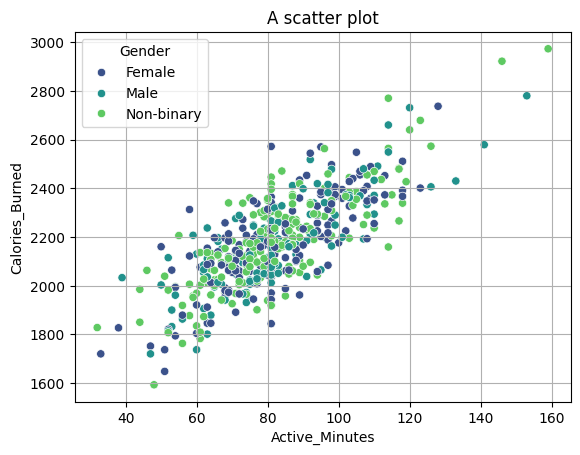

In [63]:
sns.scatterplot(
    x = 'Active_Minutes',
    y = 'Calories_Burned',
    data= df,

    hue='Gender',
    palette='viridis'
)
plt.title('A scatter plot')
plt.grid()